# Лабораторная работа 2. Пакет Matplotlib

Продолжительность работы: - 4 часа.

Мягкий дедлайн (100 баллов): 09.10.2026

Жесткий дедлайн (50 баллов): 16.10.2026


Оценка за каждое задание указана в комментариях перед заданием.

Задание выполняется самостоятельно, в противном случае все причастные получат 0 баллов :)
Если вы нашли решение любого из заданий (или его части) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце своей работы. 
В противном случае **работа также будет оценена в 0 баллов**.

### Задание 1 (1 балл)
Сгенерируйте массив нормально распределенных значений размерности 2 из 100 точек (выберите среднее значение $\mu$ и среднее квадратическое отклонение $\sigma$ по своему выбору). 
Проверьте [правило трех сигм](https://ru.wikipedia.org/wiki/%D0%A1%D1%80%D0%B5%D0%B4%D0%BD%D0%B5%D0%BA%D0%B2%D0%B0%D0%B4%D1%80%D0%B0%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%BE%D1%82%D0%BA%D0%BB%D0%BE%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5#%D0%9F%D1%80%D0%B0%D0%B2%D0%B8%D0%BB%D0%BE_%D1%82%D1%80%D1%91%D1%85_%D1%81%D0%B8%D0%B3%D0%BC): нарисуйте окружность с центром в точке $\mu$ с таким радиусом, чтобы на нее приходилось 0,99 всех точек, а также окружность радиусом 3 сигмы. 
Выделите точку $\mu$ отдельным цветом.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

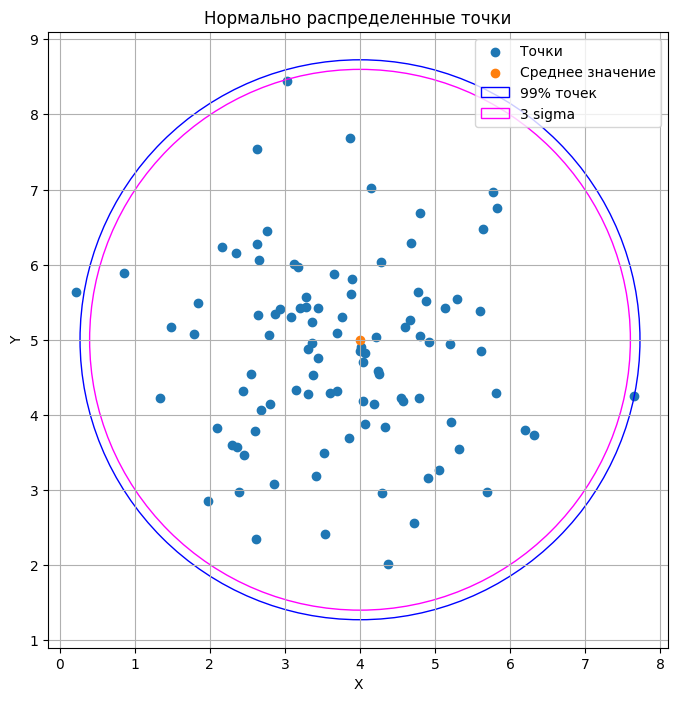

In [2]:
np.random.seed(12) #рандомные точки назначаем (книга случайный чисел!!)

mu = np.array([4,5]) # центр распредления точек (x,y)
sigma = 1.2 # мера разброса точек

points = np.random.normal(loc=mu, scale=sigma, size=(100,2)) # создаем 100 двумерных точек с нормальным распредлением (по сути 100 строк и 2 столбца)
distance = np.sqrt(np.sum((points - mu) ** 2, axis=1)) # расстояне от каждой точки до центра mu (https://v.minsk.by/1795.html) (по горизонтали)

radius_99 = np.quantile(distance, 0.99) # ищем радиус, где 99 точек
radius_3sigma = 3*sigma # радиус 3-х сигм

fig, ax = plt.subplots(figsize=(8,8)) #график

ax.scatter(points[:, 0], points[:, 1], label="Точки") #рисуем все точки (берем отдельно столбцы с x и с y)
ax.scatter(mu[0], mu[1], label = "Среднее значение")

circle_99 = plt.Circle(mu, radius_99, fill=False, edgecolor = 'blue', label = "99% точек")
circle_3sigma= plt.Circle(mu, radius_3sigma, fill=False, edgecolor = 'magenta', label="3 sigma")

#добавляем в график окружности
ax.add_patch(circle_99)
ax.add_patch(circle_3sigma)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Нормально распределенные точки")

ax.legend()
ax.grid()

ax.set_aspect("equal") # одинаковый масштаб для x и y

plt.show()

## Задание 2 

Используйте вспомогательный график, чтобы нарисовать гистограммы с 10 сегментами для каждого измерения и построить график плотности вдоль гистограммы для данных из первого задания.


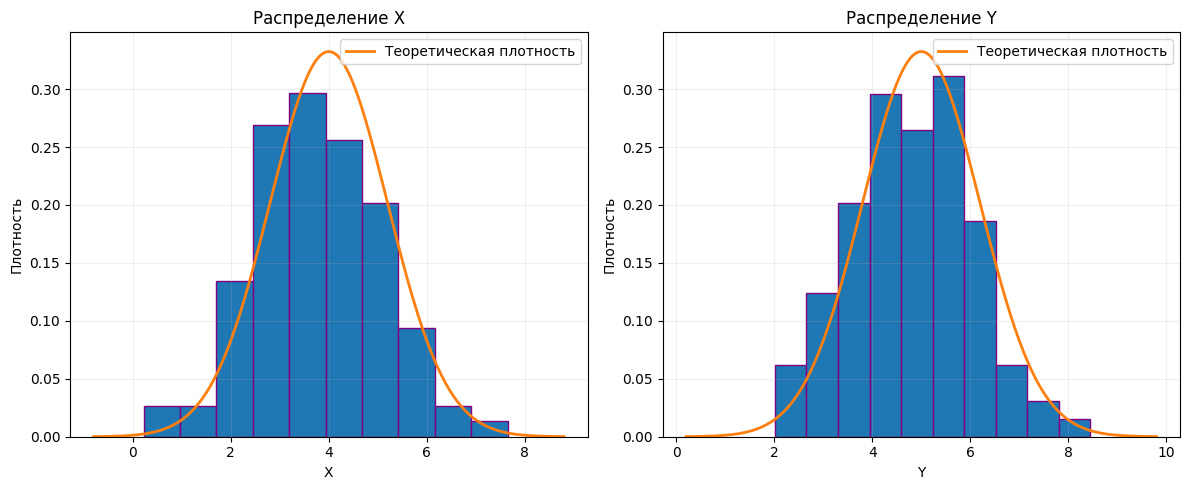

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5)) #2 графика (1 строка * 2 столбца)

#возьмем по 4 сигмы, чтобы почти вся вероятность была
x = np.linspace(mu[0] - 4 * sigma, mu[0] + 4 * sigma, 200)
y = np.linspace(mu[1] - 4 * sigma, mu[1] + 4 * sigma, 200)

#нормальное распределение плтности (https://studfile.net/preview/10473421/page:6/)
P_x = ((1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu[0]) ** 2) / (2 * sigma ** 2)))

#нормальное распределение плотности
P_y = ((1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((y - mu[1]) ** 2) / (2 * sigma ** 2)))

#гистограмму рисуем для х
ax[0].hist(points[:, 0], bins=10, density=True, edgecolor="purple")
ax[0].plot(x,P_x, linewidth=2, label="Теоретическая плотность")

ax[0].set_title("Распределение X")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Плотность")
ax[0].legend()
ax[0].grid(alpha=0.2)


#гистограмму рисуем для у
ax[1].hist(points[:, 1], bins=10, density=True, edgecolor="purple")
ax[1].plot(y, P_y, linewidth=2, label="Теоретическая плотность")

ax[1].set_title("Распределение Y")
ax[1].set_xlabel("Y")
ax[1].set_ylabel("Плотность")
ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_layout()#подбирает расстояние между рисунками
plt.show()

### Задание  3 

Загрузите набор данных ["Ирисы Фишера"](https://ru.wikipedia.org/wiki/Ирисы_Фишера). 
Создайте тепловую карту с корреляциями между объектами, строки и столбцы которой должны быть подписаны названиями объектов. 
Важно использовать matplotlib. 
Прямая корреляция должна отображаться зеленым цветом, обратная &mdash; красным, а отсутствие корреляции &mdash; белым. 
Сделайте график достаточно крупным.

**Подсказка:** используйте `plt.xticks`, `plt.yticks`, `plt.imshow`, `plt.colorbar`

In [4]:
from sklearn.datasets import load_iris #(x1,x2,x3,x4)
from matplotlib.colors import LinearSegmentedColormap


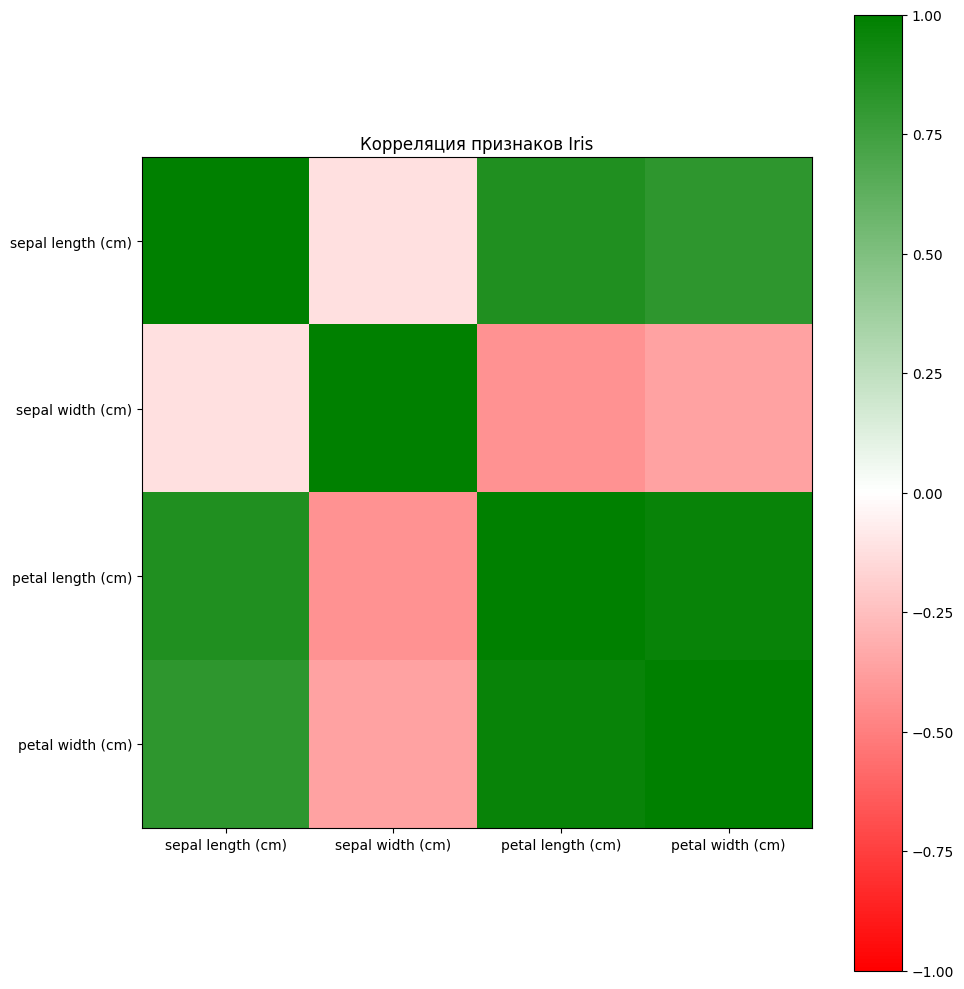

In [5]:
iris = load_iris() #загружаем ирисы
#print(iris.keys())
#print(iris['data'])
#print(iris['feature_names'])

X = iris.data
names = iris.feature_names

#print(X[0])
#print(names[0:4])

#матрица корреляций (влияние изменения одно признака на другой)
corr = np.corrcoef(X, rowvar=False) #запрещаем корреляцию по строкам
cmap = LinearSegmentedColormap.from_list("correlation", ["red", "white", "green"])
plt.figure(figsize=(10, 10))

plt.imshow(corr, cmap=cmap, vmin=-1, vmax=1)


plt.xticks(range(len(names)), names)
plt.yticks(range(len(names)), names)

plt.colorbar() #колонка с цветами
plt.title("Корреляция признаков Iris")

plt.tight_layout()
plt.show()

## Задание 4

Cоздайте такую же тепловую карту, используя `seaborn.heatmap`

In [6]:
import seaborn as sns

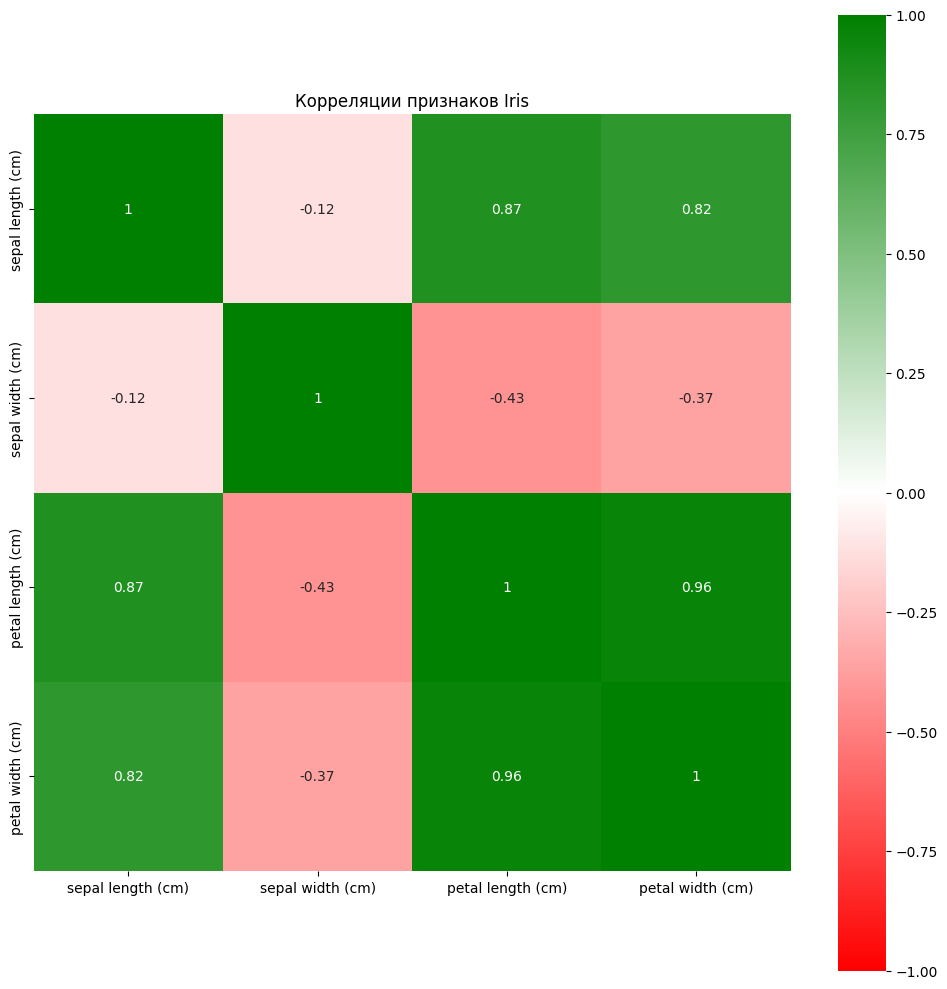

In [7]:
iris = load_iris()
X = iris.data
names = iris.feature_names

corr = np.corrcoef(X, rowvar=False) #запрещаем корреляцию по строкам
cmap = LinearSegmentedColormap.from_list("correlation", ["red", "white", "green"])
plt.figure(figsize=(10, 10))

sns.heatmap(corr, xticklabels=names, yticklabels=names, cmap=cmap, vmin=-1, vmax=1, square=True, annot=True) #числа подписаны

plt.title("Корреляции признаков Iris")
plt.tight_layout()
plt.show()